# Entrenamiento, Evaluación y Calibración — Predicción y Riesgo de ACV

Continuación de `eda.ipynb`. Partimos de `preprocessed.pkl`, que contiene `X_train_final`/`y_train_final` (balanceado con SMOTE, para comparaciones rápidas), `X_train_raw`/`y_train_raw` (sin balancear, para tuning con `Pipeline`) y `X_test_final`/`y_test_final` (con la proporción real de clases, sin tocar).

Pasos: **(1)** cargar los datos · **(2)** baselines (trivial, clínico y regresión logística) · **(3)** justificación de modelos + búsqueda de hiperparámetros y entrenamiento · **(4)** selección de umbral por modelo · **(5)** métricas del mejor modelo · **(6)** calibración de probabilidades · **(7)** conclusiones.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score, balanced_accuracy_score,
    roc_auc_score, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## 1) Cargar los datos preprocesados

In [2]:
RANDOM_STATE = 42
data = pd.read_pickle(Path.cwd() / "data/preprocessed.pkl")

X_train_final = data["X_train_final"]
y_train_final = data["y_train_final"]
X_test_final = data["X_test_final"]
y_test_final = data["y_test_final"]

# Para utilizar en modelos mas interpretables como Arbol de Clasificacion o Baseline
X_train_unscaled = data["X_train_unscaled"]
y_train_unscaled = data["y_train_unscaled"]
X_test_unscaled = X_test_baseline = data["X_test_unscaled"]  
y_test_unscaled = y_test_baseline = data["y_test_unscaled"]

X_calib_final = data["X_calib_final"]
y_calib_final = data["y_calib_final"]

print("Train:", X_train_final.shape, "| balance:", y_train_final.value_counts(normalize=True).round(3).to_dict())
print("Test: ", X_test_final.shape, "| balance:", y_test_final.value_counts(normalize=True).round(3).to_dict())
print("Calibration: ", X_calib_final.shape, "| balance:", y_calib_final.value_counts(normalize=True).round(3).to_dict())
print("Train (UNSCALED):", X_train_unscaled.shape, "| balance:", y_train_unscaled.value_counts(normalize=True).round(3).to_dict())
print("Test (UNSCALED): ", X_test_unscaled.shape, "| balance:", y_test_unscaled.value_counts(normalize=True).round(3).to_dict())

Train: (6562, 12) | balance: {0: 0.5, 1: 0.5}
Test:  (734, 12) | balance: {0: 0.958, 1: 0.042}
Calibration:  (735, 12) | balance: {0: 0.956, 1: 0.044}
Train (UNSCALED): (6562, 12) | balance: {0: 0.5, 1: 0.5}
Test (UNSCALED):  (734, 12) | balance: {0: 0.958, 1: 0.042}


## 2) Baseline: función basada en edad y BMI

Piso de comparación para evaluar los modelos. Usamos una única función simple que sólo mira **age** y **bmi** del dataset original.
$$ 
\begin{gather}
\
f(age, \ bmi) = \begin{cases} 1, & \text{Si } age \ \geq \ 60 \ \land \ bmi \ \geq \ 28 \\ 0, & \text{en otro caso} \end{cases}
\
\end{gather}
$$

In [3]:
from sklearn.base import BaseEstimator, ClassifierMixin

class BaselineModel(BaseEstimator, ClassifierMixin):
    def __init__(self, age_threshold=60, bmi_threshold=28):
        self.age_threshold = age_threshold
        self.bmi_threshold = bmi_threshold

    def fit(self, X, y=None):
        # No aprende nada, pero mantiene compatibilidad
        return self

    def predict(self, X):
        age = X["age"].values
        bmi = X["bmi"].values
        return np.where((age >= self.age_threshold) & (bmi >= self.bmi_threshold), 1, 0)

    def predict_proba(self, X):
        # Devolver probabilidades (0 o 1)
        preds = self.predict(X)
        return np.vstack([1 - preds, preds]).T

### Función de evaluación

Reunimos las métricas que importan con desbalance: `recall` (nos indica cuántos ACV reales detectamos, es importante para nuestro problema ya que queremos eveitar falsos negativos), `precision`, `f1`, `balanced_accuracy` y `roc_auc`.

In [4]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred
    return {
        "name": name,
        "model": model,
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

## 3) Seleccion de Modelos

Antes de entrenar, ¿por qué estos modelos y no otros? El dataset es tabular, tiene poco más de 5000 filas y un desbalance fuerte (~5% de ACV), y el objetivo no es solo separar las dos clases sino entregar un score de riesgo razonablemente calibrado. Con ese punto de partida elegimos cuatro modelos, cada uno representando una familia distinta de las vistas en la materia, para poder comparar enfoques y no solo variantes de lo mismo:

- **Regresión Logística:** Es un modelo sencillo, eficiente y adecuado como punto de referencia. Permite estimar directamente la probabilidad de ACV y analizar la influencia de cada variable mediante sus coeficientes. Aunque supone una relación relativamente simple entre las variables y el riesgo, su interpretación facilita entender qué factores aumentan o disminuyen el riesgo estimado.

- **Árbol de Clasificación:** Es un modelo altamente interpretable, especialmente cuando se utilizan árboles poco profundos. Sus decisiones pueden expresarse como reglas claras basadas en variables clínicas, por ejemplo, combinando edad, glucosa o hipertensión. Esto resulta apropiado en un contexto médico, ya que permite revisar cómo se obtiene cada predicción y definir una lógica de diagnóstico comprensible como apoyo a la toma de decisiones.

- **Random Forest:** Lo incluimos para evaluar si un conjunto de árboles puede mejorar las predicciones de un árbol individual. Es apropiado para este problema porque puede representar relaciones no lineales e interacciones entre distintos factores clínicos sin tener que definirlas manualmente. Además, suele ser más robusto frente al sobreajuste que un único árbol, por lo que ofrece una alternativa sólida para trabajar con datos tabulares.


- **Gradient Boosting:** Lo incluimos porque puede aprender patrones complejos en los datos mediante la combinación progresiva de modelos simples. Esta característica puede ser útil para detectar la relación conjunta entre factores como edad, glucosa, hipertensión y enfermedad cardíaca. Además, suele presentar un buen desempeño en problemas con datos tabulares, aunque requiere ajustar cuidadosamente sus hiperparámetros para evitar el sobreajuste.

## 4) Búsqueda de Hiperparámetros

En vez de entrenar cada modelo con sus valores por default, compararlos, y recién ahí tunear al o los "ganadores", buscamos los mejores hiperparámetros de **todos** los modelos primero con `GridSearchCV` (`scoring="recall"`, porque en un score de riesgo de ACV un falso negativo suele costar más que un falso positivo) y usamos directamente el mejor estimador de cada búsqueda para la comparación final. Así no entrenamos dos veces ni comparamos modelos con configuraciones no optimas.

In [5]:
model_selection = {
    "Regresion Logistica":
        {
            "model": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
            "param_grid": {"C": list(np.logspace(-4, 4, 10)) + [1]}
        },
    "Arbol de Clasificacion (Interpretable)":
        { 
            "model": DecisionTreeClassifier(random_state=RANDOM_STATE),
            # Para este arbol buscamos parametros que ayuden a su interpretablidad: baja profundidad.
            "param_grid": {"max_depth": list(np.arange(1, 5)), "min_samples_leaf": list(np.arange(5, 20)), "criterion": ["gini", "entropy"]},
            "train_data": (X_train_unscaled, y_train_unscaled),
            "test_data": (X_test_unscaled, y_test_unscaled)
        },
    "Arbol de Clasificacion":
        {
            "model": DecisionTreeClassifier(random_state=RANDOM_STATE),
            "param_grid": {"max_depth": list(np.arange(1, 20)) + [None], "min_samples_leaf": list(np.arange(1, 20)), "criterion": ["gini", "entropy"]},
        },
    "Random Forest":
        {
            "model": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
            "param_grid": {"n_estimators": [100, 300, 500], "max_depth": [None, 10, 30], "max_features": ["sqrt", "log2", 0.8, 0.5]},
        },
    "Gradient Boosting":
        {
            "model": GradientBoostingClassifier(random_state=RANDOM_STATE),
            "param_grid": {"n_estimators": [100, 300, 500], "learning_rate": [0.01, 0.05, 0.1, 0.2], "max_depth": [None, 10, 30]},
        }
}

In [6]:
def grid_search(scoring):
    results = [
        evaluate_model("Baseline", BaselineModel(), X_test_baseline, y_test_baseline),
    ]
    
    for name, details in model_selection.items():
        estimator =  details["model"]
        param_grid = details["param_grid"]
        X_train, y_train = details.get("train_data", (X_train_final, y_train_final))
        X_test, y_test = details.get("test_data", (X_test_final, y_test_final))
        
        search = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring=scoring, cv=5, n_jobs=-1)
        search.fit(X_train, y_train)
        
        print(f"{name} - Mejores parámetros: {search.best_params_} | Train {scoring}: {search.best_score_:.3f}")
        results.append(evaluate_model(name, search.best_estimator_, X_test, y_test))
        
    return results

In [7]:
scoring = "f1"
results = grid_search(scoring)
results_df = pd.DataFrame(results).drop(columns=["model"]).sort_values(scoring, ascending=False).reset_index(drop=True)
results_df

Regresion Logistica - Mejores parámetros: {'C': np.float64(2.782559402207126)} | Train f1: 0.794
Arbol de Clasificacion (Interpretable) - Mejores parámetros: {'criterion': 'gini', 'max_depth': np.int64(4), 'min_samples_leaf': np.int64(5)} | Train f1: 0.845
Arbol de Clasificacion - Mejores parámetros: {'criterion': 'entropy', 'max_depth': np.int64(17), 'min_samples_leaf': np.int64(1)} | Train f1: 0.941
Random Forest - Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300} | Train f1: 0.971
Gradient Boosting - Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 300} | Train f1: 0.970


,name,recall,precision,f1,balanced_accuracy,roc_auc
0,Regresion Logistica,0.806452,0.126263,0.218341,0.780182,0.844537
1,Arbol de Clasificacion,0.258065,0.145455,0.186047,0.595604,0.595076
2,Arbol de Clasificacion (Interpretable),0.741935,0.091270,0.162544,0.708094,0.750011
3,Baseline,0.290323,0.080357,0.125874,0.571904,0.571904
4,Random Forest,0.064516,0.125000,0.085106,0.522301,0.778782
5,Gradient Boosting,0.032258,0.083333,0.046512,0.508305,0.771991


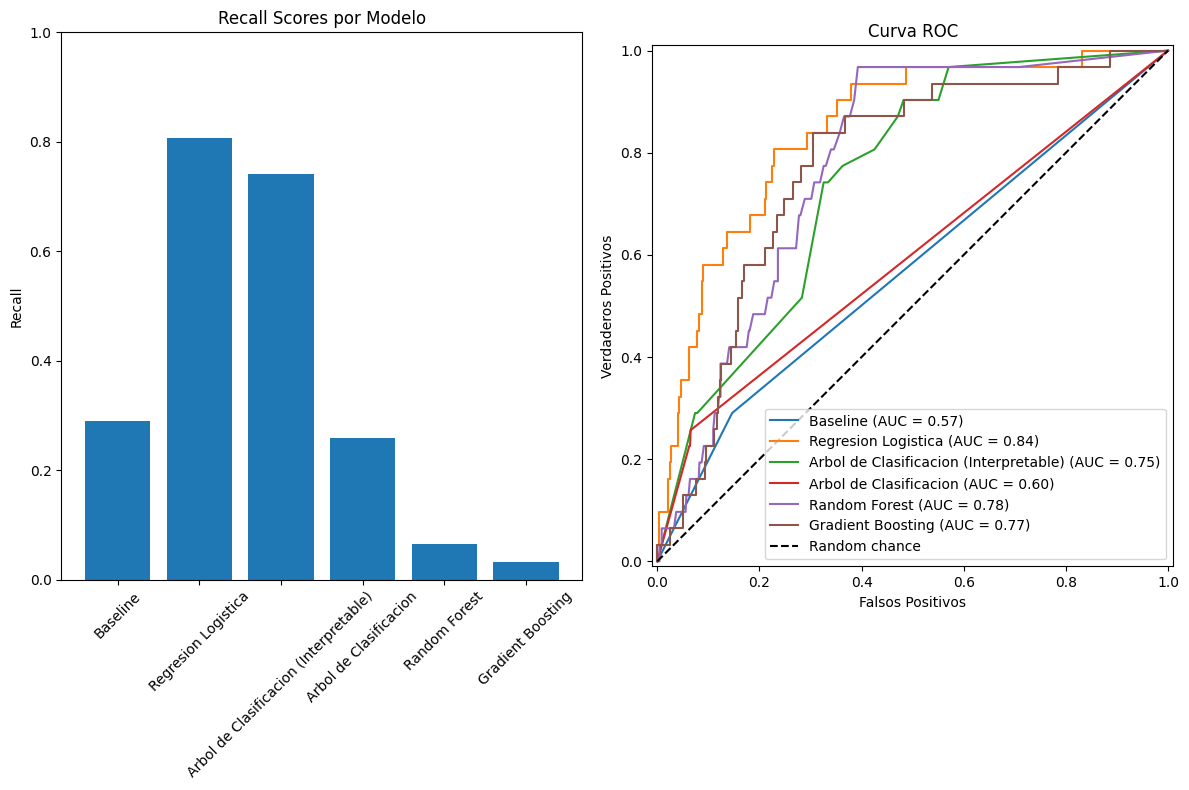

In [8]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# --- Plot 1: Recall bar chart ---
model_names = [r["name"] for r in results]
recalls = [r["recall"] for r in results]

axes[0].bar(model_names, recalls)
axes[0].set_title("Recall Scores por Modelo")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=45)

# --- Plot 2: ROC curves ---
for r in results:
    model = r["model"]
    name = r["name"]

    if name == "Baseline":
        X_test = X_test_baseline
    else:
        X_test, _ = model_selection[name].get("test_data", (X_test_final, y_test_final))
        
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test_final, y_proba, name=name, ax=axes[1])

axes[1].plot([0, 1], [0, 1], "k--", label="Random chance")
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("Falsos Positivos")
axes[1].set_ylabel("Verdaderos Positivos")
axes[1].legend()

plt.tight_layout()
plt.show()


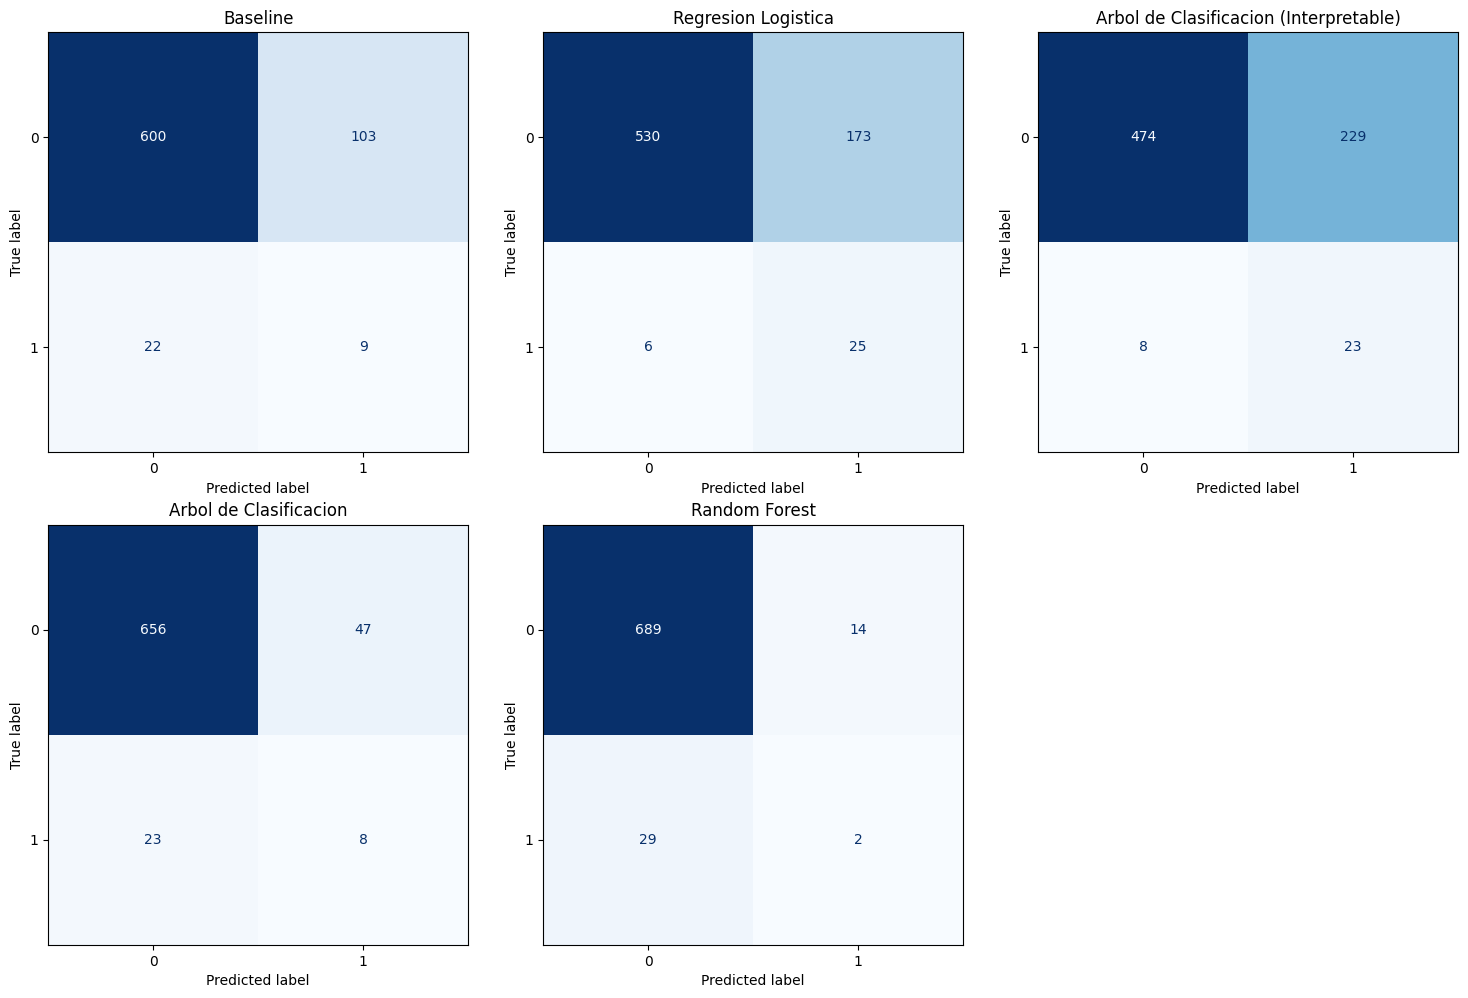

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 filas, 3 columnas
axes = axes.flatten()

for i, result in enumerate(results):
    name = result["name"]
    model = result["model"]

    if name == "Baseline":
        X_test = X_test_baseline
    else:
        X_test, _ = model_selection[name].get("test_data", (X_test_final, y_test_final))

    y_pred = model.predict(X_test)
    
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test_final, y_pred, ax=axes[i], cmap="Blues", colorbar=False
    )
    axes[i].set_title(name)

# Eliminar el subplot vacío (porque tenemos 5 modelos y 6 espacios)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


## 5) Seleccion del mejor modelo

In [10]:
best_model = next((r["model"] for r in results if r["name"] in "Regresion Logistica"))
best_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(2.782559402207126)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of p

## 6) Calibración de probabilidades

Necesaria acá por dos motivos: el proyecto entrega un **score de riesgo** (no solo una clase), y entrenamos con `SMOTE`. La cátedra lo marca como uno de los errores frecuentes de calibración: balancear para entrenar y no corregir la tasa base real deja las probabilidades **sistemáticamente infladas** respecto a la prevalencia real (~5%, no 50%).

Para corregirlo sin volver a tocar el test dos veces, partimos `X_test_final` (que conserva la proporción real) en dos mitades estratificadas: una para *calibrar* el mapeo de probabilidades y otra, separada, para la evaluación final. 

*Nota:* esto reduce el test disponible para la evaluación final. Una alternativa más prolija a futuro sería guardar en `eda.ipynb` un split de calibración tomado del train **antes** de aplicar SMOTE, para no tener que restar tamaño al test.

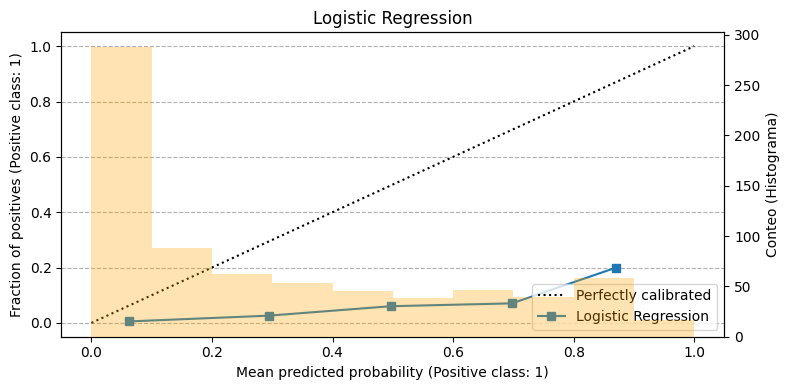

In [11]:
from sklearn.calibration import CalibrationDisplay

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

# --- Configuración común del histograma ---
hist_params = {'bins': 10, 'range': (0, 1), 'alpha': 0.3, 'color': 'orange', 'edgecolor': 'none'}

# 1. Logistic Regression
ax1 = axes
CalibrationDisplay.from_estimator(best_model, X_test_final, y_test_final, name='Logistic Regression', ax=ax1)

# Calculamos probabilidades para el histograma
probs = best_model.predict_proba(X_test_final)[:, 1]

# Creamos eje gemelo
ax1_hist = ax1.twinx()
ax1_hist.hist(probs, **hist_params)
ax1_hist.set_ylabel("Conteo (Histograma)") # Opcional
ax1.set_title("Logistic Regression")
ax1.grid(axis="y", ls='--')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import brier_score_loss, accuracy_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

proba_before = best_model.predict_proba(X_test_final)[:, 1]
brier_before = brier_score_loss(y_test_final, proba_before)
frac_pos_before, mean_pred_before = calibration_curve(y_test_final, proba_before, n_bins=10, strategy="quantile")

calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_model), method="sigmoid")
calibrated_model.fit(X_calib_final, y_calib_final)

proba_after = calibrated_model.predict_proba(X_test_final)[:, 1]
brier_after = brier_score_loss(y_test_final, proba_after)
frac_pos_after, mean_pred_after = calibration_curve(y_test_final, proba_after, n_bins=10, strategy="quantile")

print(f"Brier score antes de calibrar:  {brier_before:.4f}")
print(f"Brier score después de calibrar: {brier_after:.4f}")

Brier score antes de calibrar:  0.1639
Brier score después de calibrar: 0.0365


In [13]:
def plot_calibration_and_hist(proba_before, proba_after,
                              title_top="Curva de calibración",
                              title_bottom="Distribución de probabilidades antes y después de calibrar",
                              size=(12, 8)):
    fig, axes = plt.subplots(2, 1, figsize=size, gridspec_kw={'height_ratios': [3, 1]})

    # --- Plot superior: curva de calibración ---
    axes[0].plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")
    colors = plt.cm.Dark2.colors

    # Antes de calibrar
    frac_pos_b, mean_pred_b = calibration_curve(y_test_final, proba_before, n_bins=10, strategy="quantile")
    brier_b = brier_score_loss(y_test_final, proba_before)
    acc_b = accuracy_score(y_test_final, (proba_before >= 0.5).astype(int))
    axes[0].plot(mean_pred_b, frac_pos_b, marker="o", color=colors[0], linewidth=2,
                 label=f"Antes\nBrier={brier_b:.3f} | Acc={acc_b:.3f}")

    # Después de calibrar
    frac_pos_a, mean_pred_a = calibration_curve(y_test_final, proba_after, n_bins=10, strategy="quantile")
    brier_a = brier_score_loss(y_test_final, proba_after)
    acc_a = accuracy_score(y_test_final, (proba_after >= 0.5).astype(int))
    axes[0].plot(mean_pred_a, frac_pos_a, marker="o", color=colors[1], linewidth=2,
                 label=f"Después\nBrier={brier_a:.3f} | Acc={acc_a:.3f}")

    axes[0].set_xlabel("Probabilidad predicha media")
    axes[0].set_ylabel("Fracción de positivos reales")
    axes[0].set_title(title_top)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Plot inferior: histogramas ---
    axes[1].hist(proba_before, bins=20, alpha=0.5, label="Sin calibrar", color=colors[0])
    axes[1].hist(proba_after, bins=20, alpha=0.5, label="Calibrado", color=colors[1])
    axes[1].set_xlabel("Probabilidad")
    axes[1].set_ylabel("Frecuencia")
    axes[1].set_title(title_bottom)
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


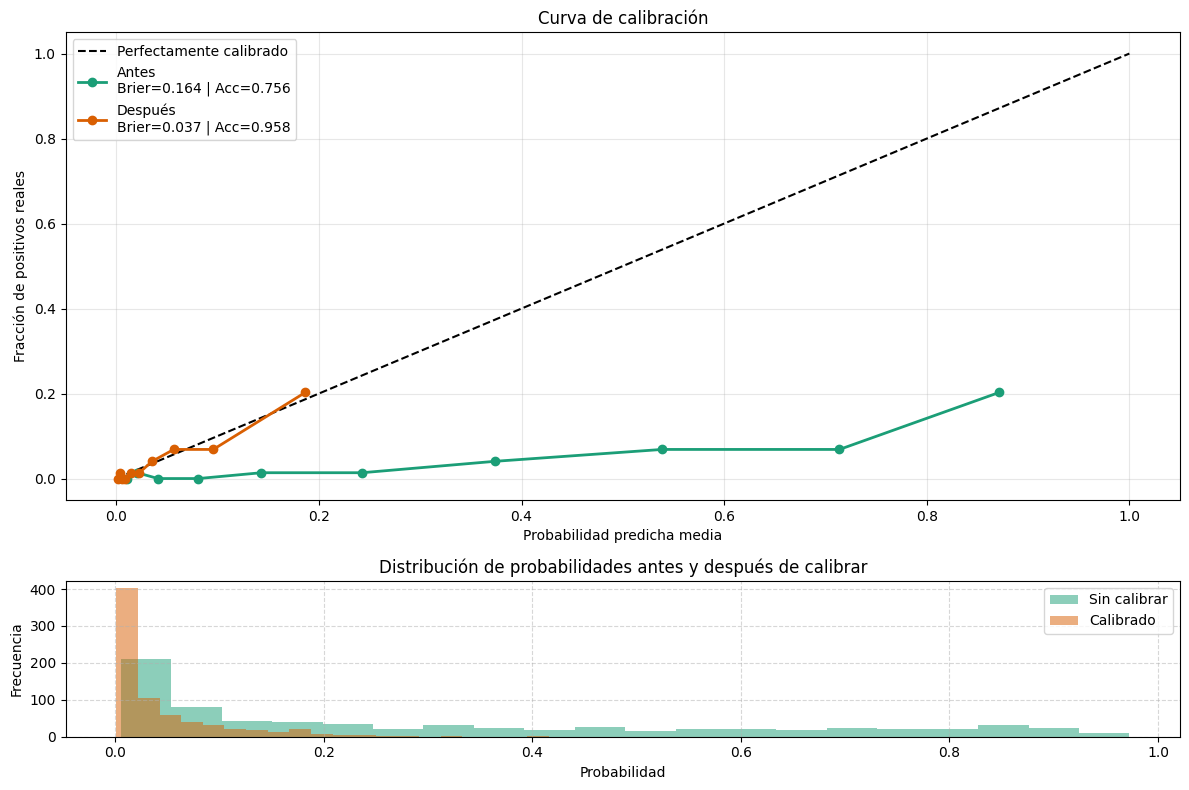

In [14]:
plot_calibration_and_hist(proba_before, proba_after)

## 7) Conclusiones